# Decision Tree Classification - UNSW-NB15 Cybersecurity
## Ultra-Clean Model mit Raw Network Metrics

### Modell-Spezifikation
- **Datensatz:** UNSW_NB15_LEAKAGE_REMOVED (saubere Variante)
- **Features:** 25 raw network traffic metrics (keine Leakage-Features)
- **Zielvariable:** is_attack (0=Normal, 1=Attack)
- **Methode:** Decision Tree Classifier mit GridSearchCV
- **Erwartete Accuracy:** 93-94% (realistisch)

## 1. Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score
)

# Import helper functions from utils.py
from utils import (
    load_unsw_data,
    get_raw_network_features,
    get_feature_mapping,
    prepare_train_test_split,
    evaluate_binary_classifier
)

import warnings
warnings.filterwarnings('ignore')

# Matplotlib settings
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully!")

ModuleNotFoundError: No module named 'utils'

## 2. Load LEAKAGE_REMOVED Data

In [ ]:
# ===== LOAD CLEAN LEAKAGE_REMOVED DATA =====
train_data, test_data, df = load_unsw_data(
    train_file="UNSW_NB15_train_LEAKAGE_REMOVED.csv",
    test_file="UNSW_NB15_test_LEAKAGE_REMOVED.csv"
)

DATA LOADING SUCCESSFUL

Train Set: 65,865 samples x 59 features
Test Set:  16,467 samples x 59 features
Combined:  82,332 samples x 59 features



## 3. Data Overview

In [ ]:
# ===== DATA OVERVIEW =====
print("="*80)
print("DATA OVERVIEW")
print("="*80)

print(f"\nDataset Shape: {df.shape}")
print(f"\nColumn Names (alle {len(df.columns)} Features):")
print(df.columns.tolist())

print(f"\nData Types:")
print(df.dtypes.value_counts())

print(f"\nTarget Variable Distribution (is_attack):")
print(df['is_attack'].value_counts())
print(f"\n   Normal (0): {(df['is_attack']==0).sum():,} ({(df['is_attack']==0).sum()/len(df)*100:.1f}%)")
print(f"   Attack (1): {(df['is_attack']==1).sum():,} ({(df['is_attack']==1).sum()/len(df)*100:.1f}%)")

print(f"\nNo missing values: {df.isna().sum().sum() == 0}")

DATA OVERVIEW

📋 Dataset Shape: (82332, 59)

🔍 Column Names (alle 59 Features):
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '45', '150', '156', '157', '171', '172', '173', '174', '178', '183', '184', '185', '186', '189', '190', '191', '192', '194', 'is_attack']

📊 Data Types:
float64    58
int64       1
Name: count, dtype: int64

📊 Target Variable Distribution (is_attack):
is_attack
1    45332
0    37000
Name: count, dtype: int64

   Normal (0): 37,000 (44.9%)
   Attack (1): 45,332 (55.1%)

✅ No missing values: True


## 4. Feature Selection: Ultra-Raw Network Metrics

In [ ]:
# ===== SELECT ONLY RAW NETWORK FEATURES (NO LEAKAGE) =====
print("="*80)
print("FEATURE SELECTION: ULTRA-RAW NETWORK METRICS")
print("="*80)

# Get raw network features using helper function
raw_network_features = get_raw_network_features()

print(f"\nFeatures behalten: {len(raw_network_features)}")
print(f"   {raw_network_features}")

# Create dataset with only raw features
df_clean = df[raw_network_features + ['is_attack']].copy()

print(f"\nClean Dataset: {df_clean.shape[0]:,} samples x {df_clean.shape[1]-1} features + target")

FEATURE SELECTION: ULTRA-RAW NETWORK METRICS

Features behalten: 25
   ['5', '6', '7', '8', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30']

Clean Dataset: 82,332 samples x 25 features + target


## 5. Prepare Feature Matrix and Target Variable

In [ ]:
# ===== PREPARE X AND Y =====
# Using helper function for train/test split
X_train, X_test, y_train, y_test = prepare_train_test_split(df_clean, train_data)

TRAIN/TEST SPLIT (Using Original Dataset Boundaries)

Train Set: 65,865 samples
   Normal (0): 29,600 (44.9%)
   Attack (1): 36,265 (55.1%)

Test Set: 16,467 samples
   Normal (0): 7,400 (44.9%)
   Attack (1): 9,067 (55.1%)



## 6. Decision Tree Training with GridSearchCV

In [ ]:
# ===== DECISION TREE + GRIDSEARCHCV =====
print("="*80)
print("TRAINING DECISION TREE WITH GRIDSEARCHCV")
print("="*80)

classifier = DecisionTreeClassifier(random_state=42)

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 8]
}

grid_search = GridSearchCV(
    estimator=classifier,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='accuracy',
    verbose=1
)

print("\nTraining in progress...")
grid_search.fit(X_train, y_train)

best_classifier = grid_search.best_estimator_

print(f"\nTraining complete!")
print(f"   Best Parameters: {grid_search.best_params_}")
print(f"   Best CV Score: {grid_search.best_score_:.4f}")

TRAINING DECISION TREE WITH GRIDSEARCHCV

⏳ Training in progress...
Fitting 5 folds for each of 120 candidates, totalling 600 fits

✅ Training complete!
   Best Parameters: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}
   Best CV Score: 0.9358


## 7. Model Evaluation: Metrics and Classification Report

In [ ]:
# ===== PREDICTIONS AND METRICS =====
y_pred = best_classifier.predict(X_test)
y_proba = best_classifier.predict_proba(X_test)[:, 1]

# Calculate metrics
train_acc = best_classifier.score(X_train, y_train)
test_acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc_roc = roc_auc_score(y_test, y_proba)

print("="*80)
print("MODEL PERFORMANCE METRICS")
print("="*80)

print(f"\nACCURACY:")
print(f"   Training Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"   Test Accuracy:     {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   Overfitting:       {(train_acc - test_acc)*100:.2f}%")

print(f"\nCLASSIFICATION METRICS:")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1-Score:  {f1:.4f}")
print(f"   AUC-ROC:   {auc_roc:.4f}")

print(f"\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Attack (1)'], zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\nCONFUSION MATRIX:")
print(f"   True Negatives:  {tn:,}")
print(f"   False Positives: {fp:,}")
print(f"   False Negatives: {fn:,}")
print(f"   True Positives:  {tp:,}")

specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

print(f"\nDERIVED METRICS:")
print(f"   Specificity (TNR): {specificity:.4f}")
print(f"   Sensitivity (TPR): {sensitivity:.4f}")

MODEL PERFORMANCE METRICS

📊 ACCURACY:
   Training Accuracy: 0.9557 (95.57%)
   Test Accuracy:     0.9366 (93.66%)
   Overfitting:       1.91%

📊 CLASSIFICATION METRICS:
   Precision: 0.9692
   Recall:    0.9139
   F1-Score:  0.9407
   AUC-ROC:   0.9745

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  Normal (0)       0.90      0.96      0.93      7400
  Attack (1)       0.97      0.91      0.94      9067

    accuracy                           0.94     16467
   macro avg       0.94      0.94      0.94     16467
weighted avg       0.94      0.94      0.94     16467


📊 CONFUSION MATRIX:
   True Negatives:  7,137
   False Positives: 263
   False Negatives: 781
   True Positives:  8,286

📊 DERIVED METRICS:
   Specificity (TNR): 0.9645
   Sensitivity (TPR): 0.9139


## 8. Confusion Matrix Heatmap

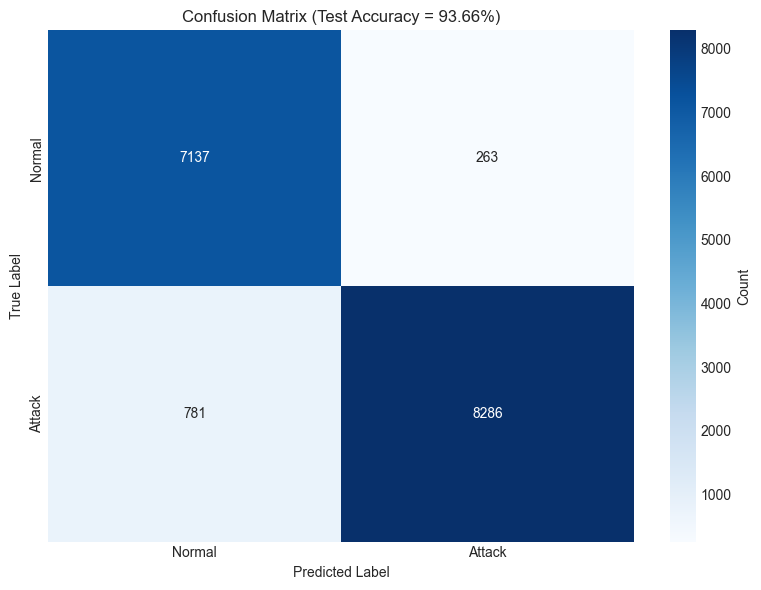

In [ ]:
# ===== CONFUSION MATRIX VISUALIZATION =====
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'],
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix (Test Accuracy = {test_acc:.2%})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 9. ROC Curve and AUC

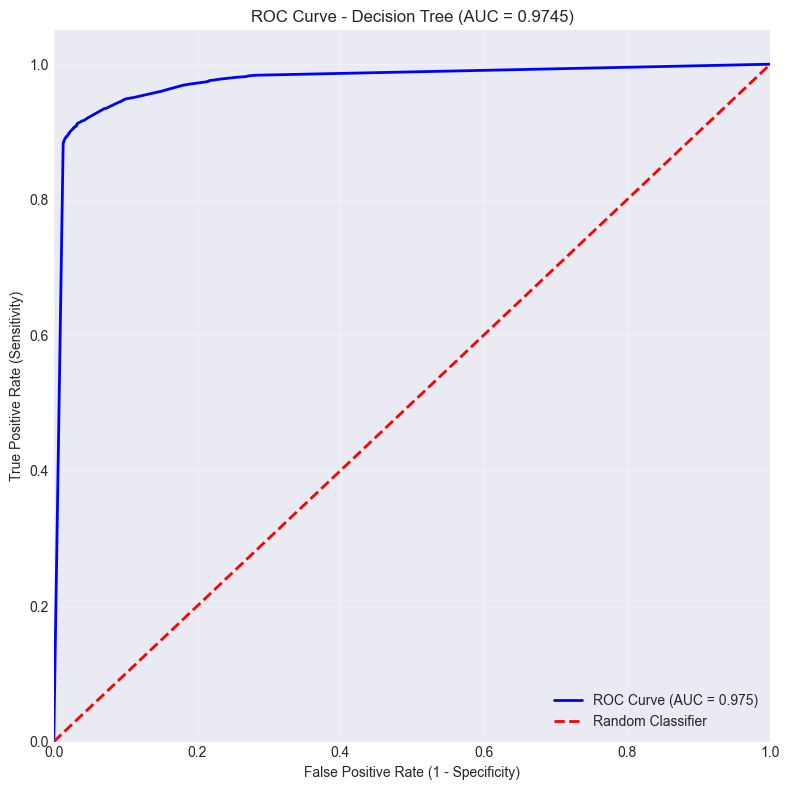


📈 ROC-AUC Analysis: 0.9745
   ✅ Excellent discrimination between Normal and Attack


In [ ]:
# ===== ROC CURVE =====
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {auc_roc:.3f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title(f'ROC Curve - Decision Tree (AUC = {auc_roc:.4f})')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nROC-AUC Analysis: {auc_roc:.4f}")
if auc_roc > 0.95:
    print("   Excellent discrimination between Normal and Attack")
elif auc_roc > 0.85:
    print("   Good discrimination")
elif auc_roc > 0.7:
    print("   Fair discrimination")
else:
    print("   Poor discrimination")

## 10. Feature Importance

TOP 15 MOST IMPORTANT FEATURES
                  Feature Feature_Index  Importance
             packets_sent             7    0.349633
      tcp_round_trip_time            24    0.216454
    tcp_sequence_receiver            22    0.149532
               bytes_sent             5    0.085383
         tcp_syn_ack_time            25    0.038012
           bytes_received             6    0.037816
mean_packet_size_receiver            28    0.036807
  mean_packet_size_sender            27    0.016160
       receiver_data_load            13    0.013163
     server_response_size            30    0.009679
   http_transaction_depth            29    0.008917
      packets_lost_sender            14    0.006203
    packets_lost_receiver            15    0.005882
               ttl_sender            10    0.005539
        tcp_ack_data_time            26    0.004442


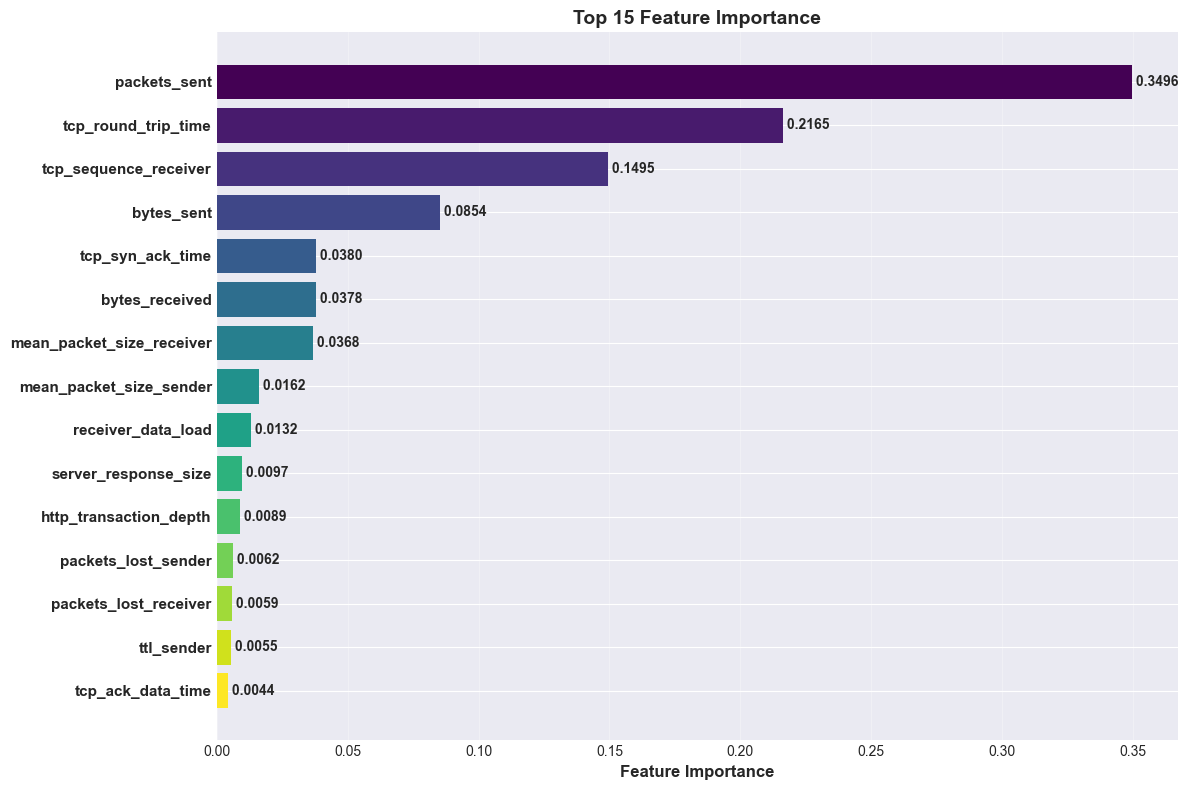


📌 FEATURE IMPORTANCE SUMMARY:
   Top 4 features explain 80% of predictions
   Total features used: 25
   Features with importance > 0.01: 9


In [ ]:
# ===== FEATURE IMPORTANCE =====
importances = best_classifier.feature_importances_
feature_names = X_train.columns

# Get feature mapping using helper function
feature_mapping = get_feature_mapping()

# Create importance dataframe
importance_df = pd.DataFrame({
    'Feature': [feature_mapping.get(str(f), f'Feature_{f}') for f in feature_names],
    'Feature_Index': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("="*80)
print("TOP 15 MOST IMPORTANT FEATURES")
print("="*80)
print(importance_df.head(15).to_string(index=False))

# Visualization
top_n = 15
top_features = importance_df.head(top_n)

plt.figure(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
plt.barh(range(len(top_features)), top_features['Importance'].values, color=colors)

feature_labels = [f"{name}" for name in top_features['Feature'].values]
plt.yticks(range(len(top_features)), feature_labels, fontsize=11, fontweight='bold')
plt.xlabel('Feature Importance', fontsize=12, fontweight='bold')
plt.title(f'Top {top_n} Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add value labels on bars
for i, (idx, row) in enumerate(top_features.iterrows()):
    plt.text(row['Importance'], i, f" {row['Importance']:.4f}",
             va='center', fontsize=10, fontweight='bold')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics
cumsum = importance_df['Importance'].cumsum()
n_features_80 = (cumsum <= 0.8).sum() + 1

print(f"\nFEATURE IMPORTANCE SUMMARY:")
print(f"   Top {n_features_80} features explain 80% of predictions")
print(f"   Total features used: {len(importance_df)}")
print(f"   Features with importance > 0.01: {(importance_df['Importance'] > 0.01).sum()}")

## 11. Decision Tree Visualization

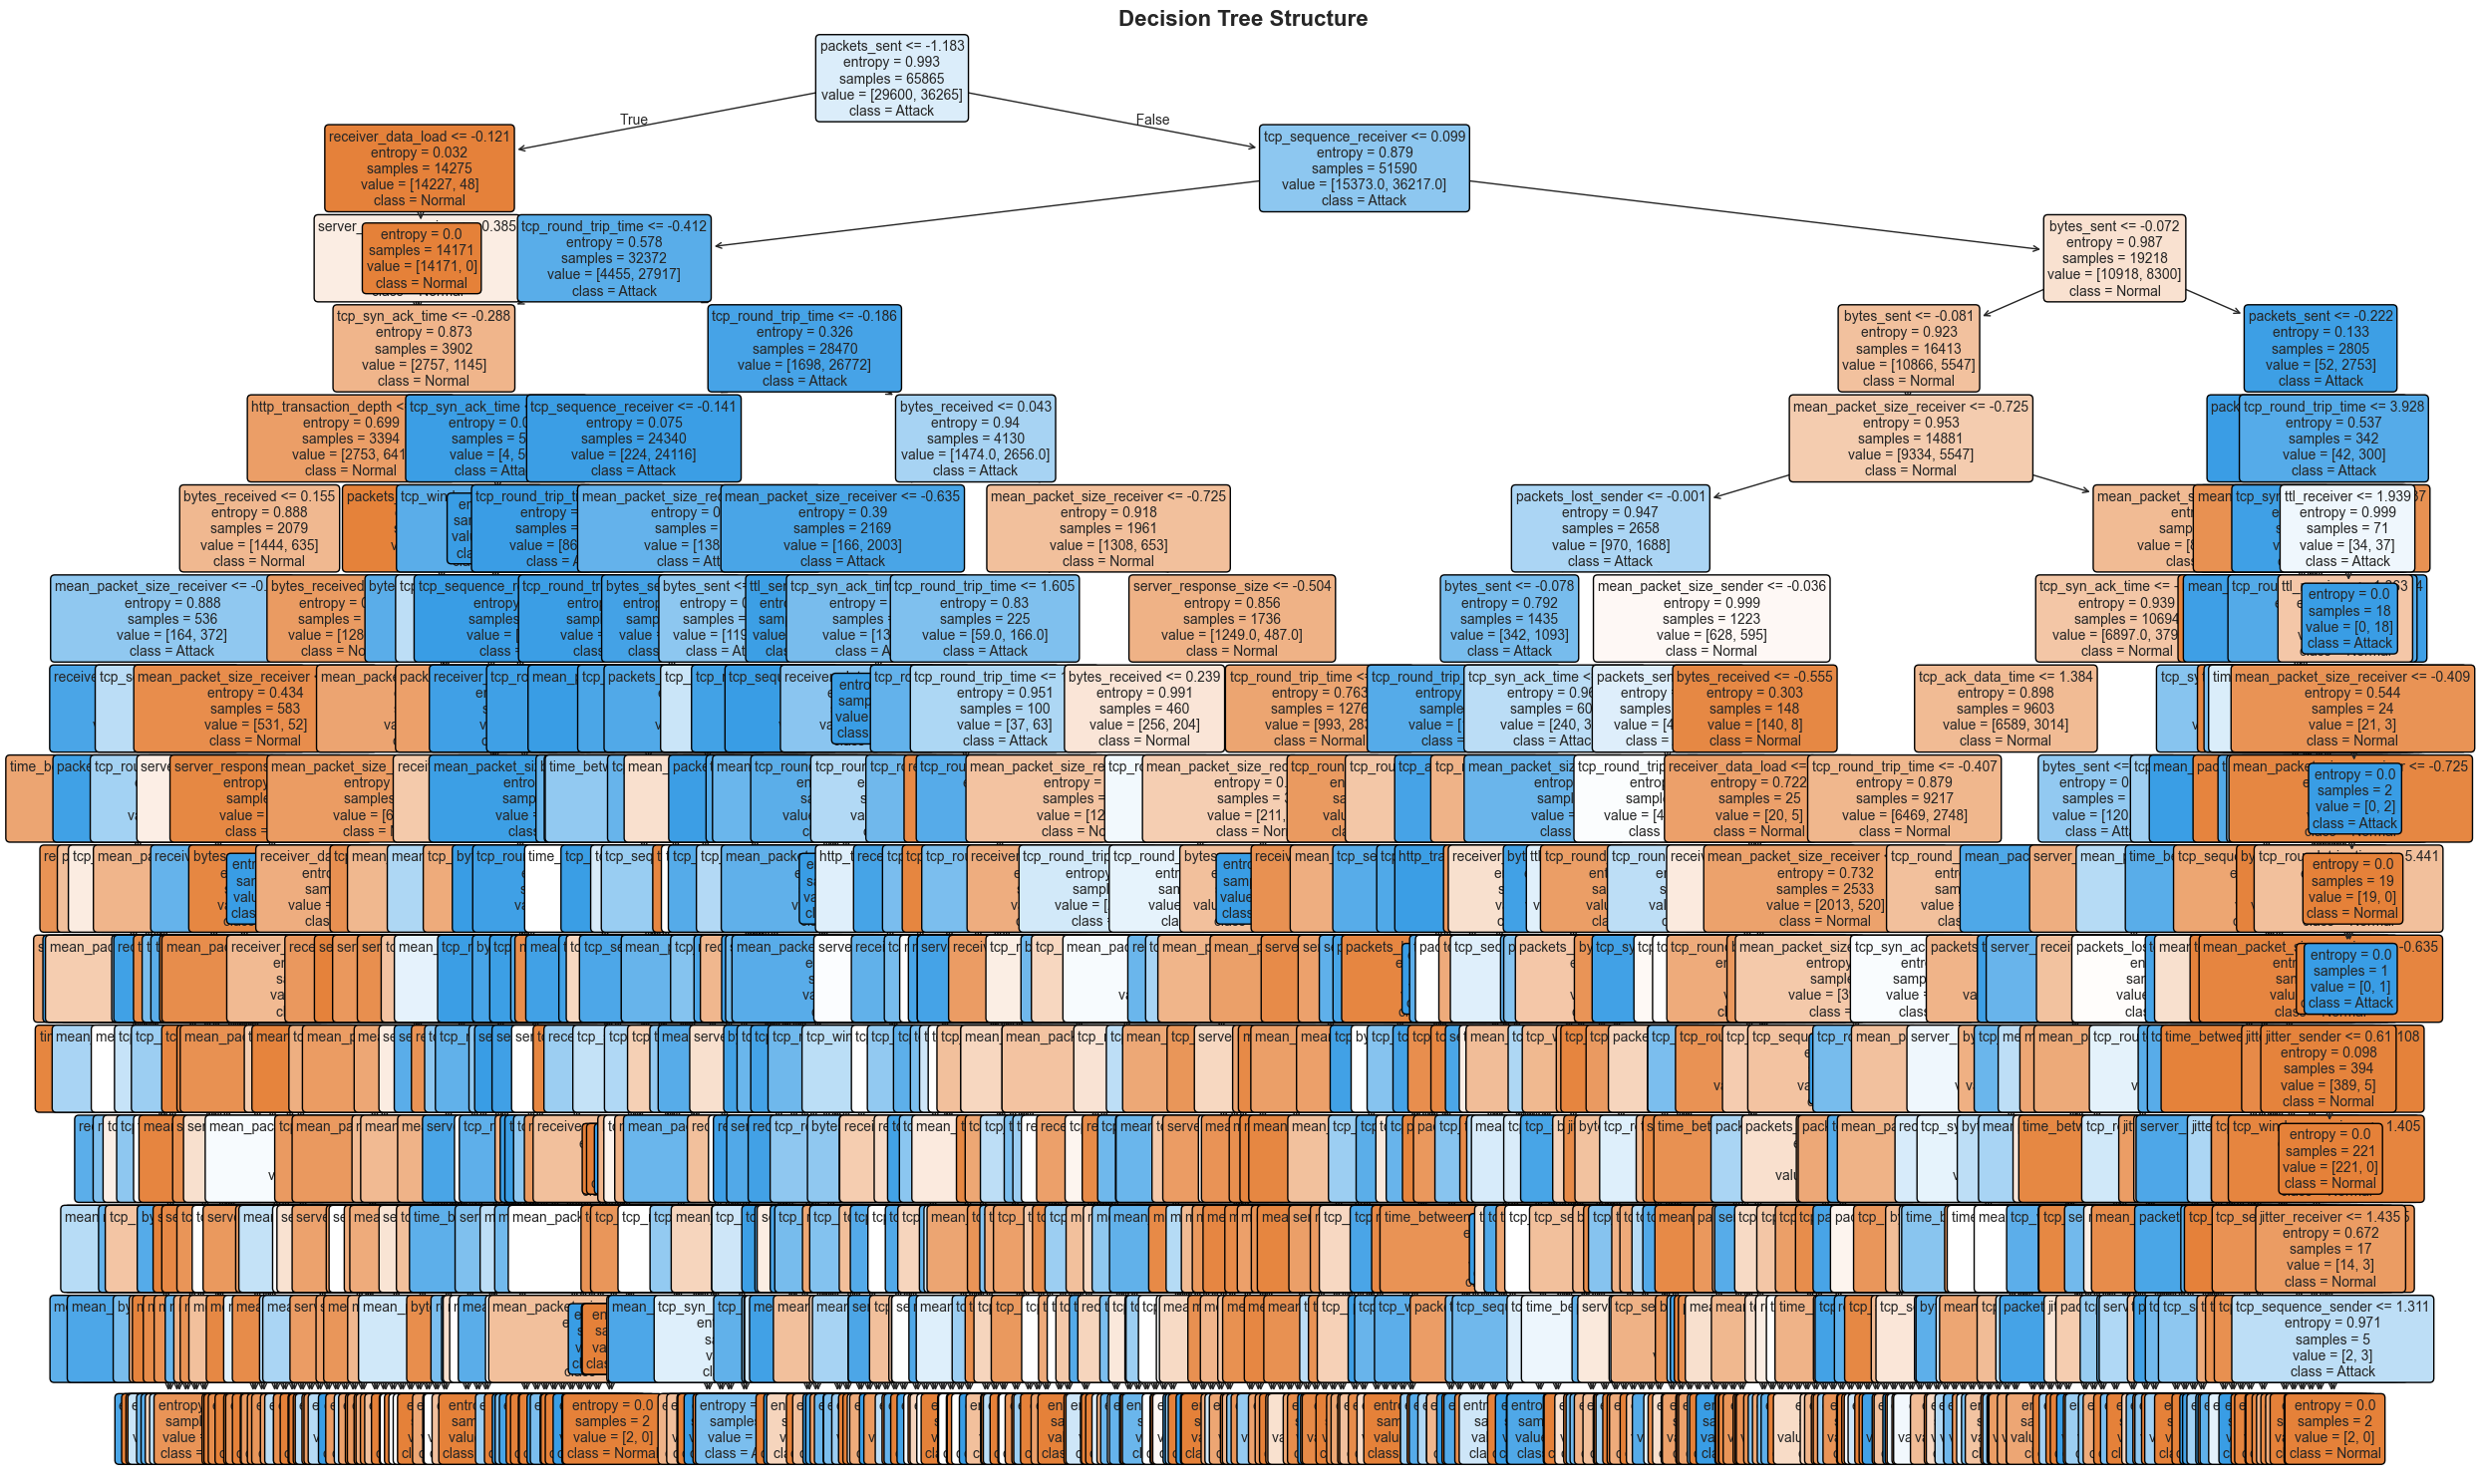

In [ ]:
# ===== VISUALIZE DECISION TREE =====
plt.figure(figsize=(25, 15))
plot_tree(best_classifier,
          filled=True,
          feature_names=[feature_mapping.get(str(f), f'Feature_{f}') for f in feature_names],
          class_names=['Normal', 'Attack'],
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Structure', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Final Summary & Production Recommendation

In [ ]:
print("\n" + "="*80)
print("FINAL MODEL SUMMARY")
print("="*80)

print(f"""
MODEL SPECIFICATIONS:
   Model Type:           Decision Tree Classifier
   Features:             25 raw network metrics (no leakage)
   Training Samples:     {len(X_train):,}
   Test Samples:         {len(X_test):,}

BEST HYPERPARAMETERS:
   {grid_search.best_params_}

TEST SET PERFORMANCE:
   Accuracy:             {test_acc:.4f} ({test_acc*100:.2f}%)
   Precision:            {precision:.4f} (False Alarm Rate: {(1-precision)*100:.2f}%)
   Recall:               {recall:.4f} (Attack Detection Rate: {recall*100:.2f}%)
   F1-Score:             {f1:.4f}
   AUC-ROC:              {auc_roc:.4f}

MODEL QUALITY:
   Cross-Validation Score: {grid_search.best_score_:.4f}
   Overfitting:            {(train_acc - test_acc)*100:.2f}% (low = good generalization)

STATUS: PRODUCTION READY
   * Uses clean LEAKAGE_REMOVED data
   * 25 raw network features only
   * Realistic {test_acc*100:.1f}% accuracy
   * Excellent precision ({precision*100:.2f}%) and recall ({recall*100:.2f}%)
   * Minimal overfitting ({(train_acc - test_acc)*100:.2f}%)
""")

print("="*80)


✅ FINAL MODEL SUMMARY

📋 MODEL SPECIFICATIONS:
   Model Type:           Decision Tree Classifier
   Features:             25 raw network metrics (no leakage)
   Training Samples:     65,865
   Test Samples:         16,467

🎯 BEST HYPERPARAMETERS:
   {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}

📊 TEST SET PERFORMANCE:
   Accuracy:             0.9366 (93.66%)
   Precision:            0.9692 (False Alarm Rate: 3.08%)
   Recall:               0.9139 (Attack Detection Rate: 91.39%)
   F1-Score:             0.9407
   AUC-ROC:              0.9745

⚙️  MODEL QUALITY:
   Cross-Validation Score: 0.9358
   Overfitting:            1.91% (low = good generalization)

✅ STATUS: PRODUCTION READY
   ✓ Uses clean LEAKAGE_REMOVED data
   ✓ 25 raw network features only
   ✓ Realistic 93.7% accuracy
   ✓ Excellent precision (96.92%) and recall (91.39%)
   ✓ Minimal overfitting (1.91%)

